
# Extreme Deconvolution

## Introduction

### Why do we need this?

Every quantity we measure in astronomy comes with a **measurement error**. A star's color, brightness, position — they all arrive with some uncertainty attached. And that uncertainty isn't the same for every object: bright stars are measured precisely, faint stars are measured noisily.

This creates a problem. Suppose we want to know the **true underlying distribution** of some population, so we histogram our measurements. The distribution we get always looks **wider** than the real one, because measurement error smears it out. In other words, what we observe is

$$
\text{observed distribution} = \text{true distribution} \;\circledast\; \text{measurement error}
$$

— the true distribution **convolved** with noise ($\circledast$ denotes convolution). What we actually want is the term on the right, not the smeared thing on the left.
**Extreme deconvolution (XD)** undoes this convolution (it *deconvolves*) to recover the underlying distribution with the measurement error stripped back out.

### The key idea

XD models the true distribution as a sum of Gaussians — a **Gaussian Mixture Model (GMM)**:
$$p(v) = \sum_{k=1}^{K} \alpha_k\,\mathcal{N}(v \mid \mu_k, V_k)$$

Here $v$ is the error-free true value, $\mu_k$ and $V_k$ are the center and width of the $k$-th Gaussian, and $\alpha_k$ is its weight ($\sum_k \alpha_k = 1$).
But what we actually observe is not the true value $v_i$ — it's $v_i$ plus that object's own measurement error $S_i$:

$$
x_i = v_i + (\text{noise with covariance } S_i)
$$

The crucial part of XD is that the model is fit **knowing each point's measurement error $S_i$ in advance**. If we marginalize over the unknown true value, the likelihood of an observed point becomes

$$
p(x_i) = \sum_{k=1}^{K} \alpha_k\,\mathcal{N}\!\left(x_i \mid \mu_k,\ V_k + S_i\right)
$$

This single equation is all of XD. It differs from an ordinary GMM in exactly one place: **each Gaussian's covariance has that point's measurement error $S_i$ added to it.** What this means:

> XD knows that part of the observed scatter — the amount $S_i$ — is just noise, so the widths $V_k$ it recovers are **narrower** than the observed spread. That narrowing is the deconvolution.

A direct comparison makes it clear:

- **Ordinary GMM** (ignores errors): fits Gaussians to the observed data → recovered width $\approx$ true width $+$ noise. Inflated.
- **XD** (uses errors): fits with the noise subtracted out → recovered width $\approx$ true width. ✓

### What we'll see in this notebook

We check that XD really works in two ways:

- **Part A — synthetic data:** we build a true distribution ourselves → deliberately add noise → use XD to recover the true distribution, and see how well it matches the original. Because we know the right answer, this is a clean test.
- **Part B — real stellar data:** we treat high-quality data (coadded standard stars) as the "right answer," run XD on the noisy single-epoch measurements of the *same* stars, and check whether the recovered distribution comes close to that answer. In a real application you wouldn't have this answer key — only the noisy data — but here we line them up side by side to confirm XD can be trusted.

## Import Data and Functions

The main tool we need is `XDGMM` from `astroML` — this is the class that performs extreme deconvolution (it fits the noise-aware Gaussian mixture from the Introduction).

For the real-data example (Part B) we use two catalogs of the *same* stars:
- **Stripe 82 Standard Star Catalog** — built by coadding many repeat observations, so the measurements are very precise (high SNR). We treat this as the "right answer."
- **Single-epoch observations** — each star measured just once, so the measurements are noisy (low SNR). This is the data we actually run XD on.

More information about the data is in the references.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

from astroML.density_estimation import XDGMM
#from astroML.plotting.tools import draw_ellipse

from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## A. XD on a generated dataset
In the first section, we will explore how XD works using randomly generated data set.

### A-1. Generate the "true" data

We start by building a distribution of "true" data that we fully control, so that later we can check XD against a known answer.

Note that the true distribution is built in **two stages**:
1. A clean underlying curve, $y = 0.1\,x^2$.
2. Some **intrinsic scatter** added around that curve.

The result of these two stages — curve *plus* intrinsic scatter — is what we call the "true distribution," and it is the thing we will try to recover. In the next step we add a *separate* layer of **measurement noise** on top; XD is meant to remove that measurement noise and bring us back to this true distribution.

You can change the sample size `N`: a larger `N` gives the algorithm more information and converges more easily, but runs slower. Too small an `N` may fail to converge.

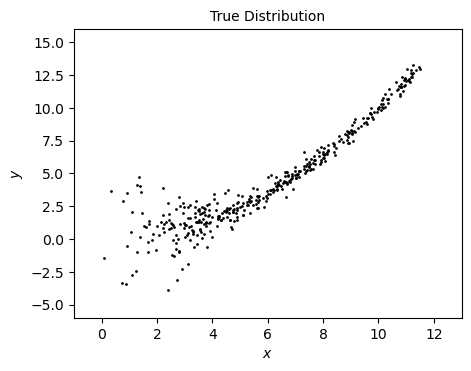

In [25]:
# Sample the dataset.
# Here we use sample size = 400, which converges quickly and gives a reasonable result.
N = 400
np.random.seed(0)

# Stage 1: the clean underlying curve
x_true = (1.4 + 2 * np.random.random(N)) ** 2
y_true = 0.1 * x_true ** 2

# Stage 2: add intrinsic scatter around the curve.
# Curve + this scatter = the "true distribution" we want XD to recover later.
dx = 0.1 + 4. / x_true ** 2
dy = 0.1 + 10. / x_true ** 2

x_true += np.random.normal(0, dx, N)
y_true += np.random.normal(0, dy, N)

# helper: plot any (x, y) distribution in a common format
def plot_distribution(text, sample_x, sample_y):
    plt.figure(figsize=(5, 3.75))
    plt.scatter(sample_x, sample_y, s=4,lw=0,c='k')
    plt.xlim(-1, 13)
    plt.ylim(-6, 16)
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(text,fontsize=10)

# plot true distribution
plot_distribution('True Distribution', x_true, y_true)

plt.show()

### A-2. Generate noisy data
We add some radom noisy onto the true data to model what we may observe from true distribution.

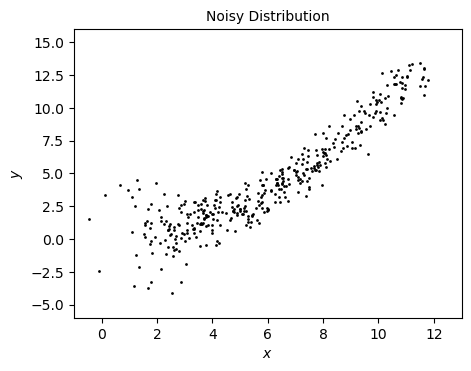

In [26]:
# add noise to get the "observed" distribution
dx = 0.2 + 0.5 * np.random.random(N)
dy = 0.2 + 0.5 * np.random.random(N)

x = x_true + np.random.normal(0, dx)
y = y_true + np.random.normal(0, dy)

# plot noisy distribution
plot_distribution('Noisy Distribution', x, y)

### A-3. Compute the extreme deconvolution (XD)

Now we run XD. Two settings connect directly to the model in the Introduction:
- `n_components` $= K$, the number of Gaussians in the mixture $p(v)=\sum_k \alpha_k\,\mathcal{N}(\mu_k,V_k)$.
- `max_iter` / `tol` control the **EM algorithm** that maximizes the log-likelihood: `max_iter` caps the number of iterations and `tol` sets how small a change counts as "converged." More iterations generally means a better fit but a longer run.

This cell takes roughly a minute to run.

In [27]:
# Stack x and y into a single array of shape (N, 2): one row per object.
X = np.vstack([x, y]).T

# Build the per-object measurement-error covariance S_i (called Xerr here).
# KEY POINT: every object gets its OWN 2x2 covariance matrix, so Xerr has shape (N, 2, 2).
# Here the x and y errors are independent, so each matrix is diagonal:
#   [[dx^2, 0   ],
#    [0,    dy^2]]
# This is the S_i from the Introduction; XDGMM adds it to each Gaussian's covariance.
Xerr = np.zeros(X.shape + X.shape[-1:])
diag = np.arange(X.shape[-1])
Xerr[:, diag, diag] = np.vstack([dx ** 2, dy ** 2]).T

clf = XDGMM(n_components=10, max_iter=200)

clf.fit(X, Xerr)

# sample() draws NEW points from the recovered underlying distribution p(v).
# (It does not "fix" individual observed points; it regenerates the cleaned distribution.)
sample = clf.sample(N)

### A-4. Plot the result from XD
We use scattered point to show the result of noisy data from XD correction. The plot shows a less scattered distribution 
than noisy data and even than true data, which better portraits a "underlying distribution."

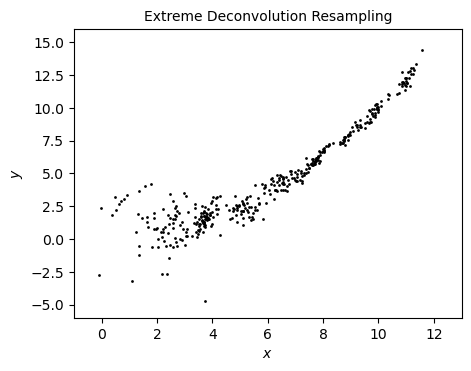

In [28]:
# plot noisy distribution
plot_distribution('Extreme Deconvolution Resampling', sample[:, 0], sample[:, 1])

### A-5. Compare everything side by side

We put four panels together: the true distribution (top left), the noisy distribution (top right), the XD-resampled distribution (bottom left), and the recovered model components (bottom right).

The ellipses in the bottom-right panel **are** the Gaussian components of the recovered mixture, $\mathcal{N}(\mu_k, V_k)$ — each drawn at the $2\sigma$ level. Together they make up the model $p(v)=\sum_k \alpha_k\,\mathcal{N}(\mu_k,V_k)$ from the Introduction: the noise-free description of the data that XD has inferred.


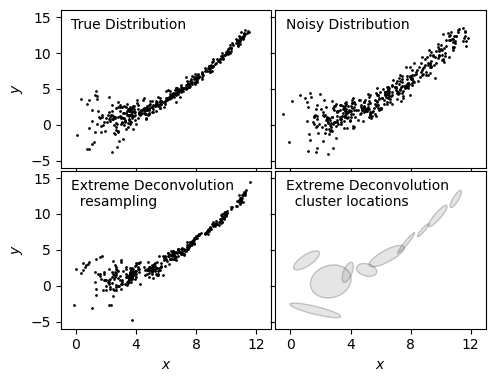

In [29]:
# Plot the results

from matplotlib.patches import Ellipse
def draw_ellipse_(mu, C, scales=[1, 2, 3], ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()

    # find principal components and rotation angle of ellipse
    sigma_x2 = C[0, 0]
    sigma_y2 = C[1, 1]
    sigma_xy = C[0, 1]

    alpha = 0.5 * np.arctan2(2 * sigma_xy,
                             (sigma_x2 - sigma_y2))
    tmp1 = 0.5 * (sigma_x2 + sigma_y2)
    tmp2 = np.sqrt(0.25 * (sigma_x2 - sigma_y2) ** 2 + sigma_xy ** 2)

    sigma1 = np.sqrt(tmp1 + tmp2)
    sigma2 = np.sqrt(tmp1 - tmp2)
    for scale in scales:
        ax.add_patch(Ellipse((mu[0], mu[1]),
                             2 * scale * sigma1, 
                             2 * scale * sigma2,
                             angle=alpha * 180. / np.pi,
                             **kwargs))
# ---------------------------------------------------------------
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(left=0.1, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

ax1 = fig.add_subplot(221)
ax1.scatter(x_true, y_true, s=4, lw=0, c='k')

ax2 = fig.add_subplot(222)
ax2.scatter(x, y, s=4, lw=0, c='k')

ax3 = fig.add_subplot(223)
ax3.scatter(sample[:, 0], sample[:, 1], s=4, lw=0, c='k')

ax4 = fig.add_subplot(224)

# Each ellipse is one Gaussian component N(mu_k, V_k) of the recovered mixture, at 2 sigma.
for i in range(clf.n_components):
    draw_ellipse_(clf.mu[i], clf.V[i], scales=[2], ax=ax4,
                ec='k', fc='gray', alpha=0.2)

titles = ["True Distribution", "Noisy Distribution",
          "Extreme Deconvolution\n  resampling",
          "Extreme Deconvolution\n  cluster locations"]

ax = [ax1, ax2, ax3, ax4]

for i in range(4):
    ax[i].set_xlim(-1, 13)
    ax[i].set_ylim(-6, 16)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(4))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    if i in (0, 1):
        ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_xlabel('$x$')

    if i in (1, 3):
        ax[i].yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_ylabel('$y$')


### Try it yourself

1. **Number of components.** Change `n_components` (try 1, 3, 10) in step A-3 and re-run. What happens with too few components? With many? This is the trade-off between under- and over-fitting.
2. **Sample size.** Change `N` in step A-1. Very small samples may fail to converge — try it and see.
3. **Wrong error estimates.** Deliberately multiply `Xerr` by, say, 4 (too large) or 0.25 (too small) before fitting, and compare the recovered distribution. XD trusts the errors you give it — if they are wrong, the deconvolution goes wrong too. This is the single most important assumption of the method.

### Discussion question (looking ahead to Part B)

In Part B we won't hand XD the error on each color directly — we'll start from errors on the *magnitudes* and convert. The magnitude errors are independent, but the resulting color errors turn out to be **correlated**. Why would measuring colors (differences of magnitudes) create correlations between their errors, even when the magnitude errors themselves are independent? Keep this in mind; the W-matrix step in Part B answers it.

## B. XD on a real stellar sample

Now we apply XD to real stars instead of made-up data.

**The physics.** A star's broadband colors are set almost entirely by a single property — its surface temperature. Because of that, stars don't fill up color–color space; they fall along a thin, roughly one-dimensional curve called the **stellar locus**. In a perfect measurement the locus would be razor-thin.

Real measurements blur it. Noisy single-epoch photometry spreads stars out, making the locus look fat. The goal of this part is to check whether XD can recover the intrinsically thin locus from the noisy data alone.

We use two catalogs of the **same** stars: high-SNR coadded standard stars (our "right answer," a naturally thin locus) and their noisy single-epoch measurements (a fat locus). We run XD on the noisy data and see whether the recovered locus matches the standard-star answer.

### B-1. Extinction correction on the noisy sample

Dust along the line of sight makes starlight redder and fainter — this is **extinction**. Before comparing colors we correct for it. The correction per band follows a fixed curve $C_{\lambda} \equiv A_{\lambda}/A_r$, with the per-band coefficients taken from [Berry et al. 2012](https://ui.adsabs.harvard.edu/abs/2012ApJ...757..166B/abstract). This is a data-preparation step — it just puts every star on the same footing.

In [30]:
# Per-band extinction coefficients (u, g, r, i, z) from Berry et al. 2012; scaled by A_r below.
extinction_vector = np.array([1.810, 1.400, 1.0, 0.759, 0.561])

# Fetch the noisy single-epoch imaging data
data_noisy = fetch_imaging_sample()

# keep only stars (SDSS object type code 6 = star)
data_noisy = data_noisy[data_noisy['type'] == 6]

# Stack the per-band PSF magnitudes and their errors (one row per star)
X = np.vstack([data_noisy[f + 'RawPSF'] for f in 'ugriz']).T
Xerr = np.vstack([data_noisy[f + 'psfErr'] for f in 'ugriz']).T

# apply the extinction correction
X -= (extinction_vector * data_noisy['rExtSFD'][:, None])

### B-2. Extinction correction on the standard sample

We apply the same extinction correction to the high-SNR standard stars, then keep only well-measured, reasonably bright stars (a quality cut).

In [31]:
# Fetch and process the stacked imaging data
data_stacked = fetch_sdss_S82standards()

# cut to RA, DEC range of imaging sample
RA = data_stacked['RA']
DEC = data_stacked['DEC']
data_stacked = data_stacked[(RA > 0) & (RA < 10) &
                            (DEC > -1) & (DEC < 1)]

# get stacked magnitudes for each band
Y = np.vstack([data_stacked['mmu_' + f] for f in 'ugriz']).T
Yerr = np.vstack([data_stacked['msig_' + f] for f in 'ugriz']).T

# extinction terms from Berry et al, arXiv 1111.4985
Y -= (extinction_vector * data_stacked['A_r'][:, None])

# quality cuts: keep stars with small errors in all bands (< 0.05) and g < 20
g = Y[:, 1]
mask = ((Yerr.max(1) < 0.05) &
        (g < 20))
data_stacked = data_stacked[mask]
Y = Y[mask]
Yerr = Yerr[mask]

### B-3. Cross-match the two catalogs

To compare "the same star, measured two ways," we match each noisy star to its standard-star counterpart by sky position (within 0.9 arcsec). After this step the two arrays line up row-by-row: row $i$ of the noisy data and row $i$ of the standard data are the same star.

In [32]:
Xlocs = np.hstack((data_noisy['ra'][:, np.newaxis],
                   data_noisy['dec'][:, np.newaxis]))
Ylocs = np.hstack((data_stacked['RA'][:, np.newaxis],
                   data_stacked['DEC'][:, np.newaxis]))

print("number of noisy points:  ", Xlocs.shape)
print("number of stacked points:", Ylocs.shape)

# find all points within 0.9 arcsec.  This cutoff was selected
# by plotting a histogram of the log(distances).
dist, ind = crossmatch(Xlocs, Ylocs, max_distance=0.9 / 3600)

noisy_mask = (~np.isinf(dist))
stacked_mask = ind[noisy_mask]

# select the data
data_noisy = data_noisy[noisy_mask]
X = X[noisy_mask]
Xerr = Xerr[noisy_mask]

data_stacked = data_stacked[stacked_mask]
Y = Y[stacked_mask]
Yerr = Yerr[stacked_mask]

# double-check that our cross-match succeeded
assert X.shape == Y.shape
print("size after crossmatch:", X.shape)

number of noisy points:   (82003, 2)
number of stacked points: (13377, 2)
size after crossmatch: (12313, 5)


### B-4. From magnitudes to colors, and propagating the errors

**Why colors?** The stellar locus is cleanest in **color** space, so instead of working with the five magnitudes directly we work with one magnitude plus four colors: $(g,\ u\!-\!g,\ g\!-\!r,\ r\!-\!i,\ i\!-\!z)$.

This is just a **linear transformation** of the magnitude vector, written with a mixing matrix $W$:

$$\text{(color vector)} = W \cdot \text{(magnitude vector)}.$$

**Propagating the errors.** When you apply a linear transformation $W$ to data, the covariance transforms as

$$C_{\text{color}} = W\, C_{\text{mag}}\, W^{\top}.$$

Here is the important part. The raw magnitude errors are **independent**, so $C_{\text{mag}}$ is diagonal. But each color is a *difference of two magnitudes*, and neighboring colors share a magnitude (for example $g\!-\!r$ and $r\!-\!i$ both involve $r$). Sharing a magnitude makes their errors **correlated**, so $C_{\text{color}}$ picks up **off-diagonal** terms.

That is exactly why XD needs a full covariance matrix $S_i$ per object, not just a separate error bar on each axis: once we move to colors, the axes are no longer independent.

In [33]:
# Mixing matrix W: maps (u, g, r, i, z) magnitudes -> (g, u-g, g-r, r-i, i-z)
W = np.array([[0, 1, 0, 0, 0],    # g magnitude
              [1, -1, 0, 0, 0],   # u-g color
              [0, 1, -1, 0, 0],   # g-r color
              [0, 0, 1, -1, 0],   # r-i color
              [0, 0, 0, 1, -1]])  # i-z color

# transform each object's magnitudes into colors
X = np.dot(X, W.T)
Y = np.dot(Y, W.T)

# Build the diagonal magnitude-error covariance for every object (shape (N, 5, 5))
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2

# Propagate into color space: C_color = W C_mag W^T, applied to every object at once.
# (tensordot just does this matrix product for the whole stack.)
Xcov = np.tensordot(np.dot(Xcov, W.T), W, (-2, -1))

### B-5. Plot the two raw datasets

Before running XD, we plot 10% of the stars from each catalog in the $g\!-\!r$ vs $r\!-\!i$ color–color plane. The standard stars (left) trace a tight locus; the single-epoch data (right) are visibly fatter — that extra width is measurement noise, and it is what XD will try to remove.

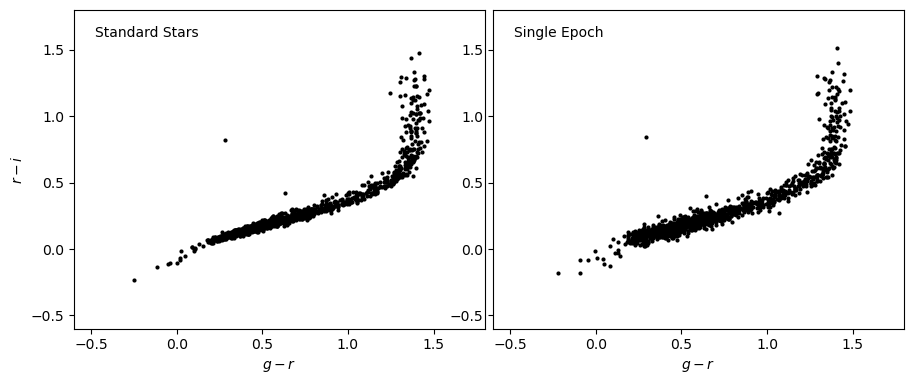

In [34]:
# Plot 10% of the stars from each catalog (raw, before XD)
fig = plt.figure(figsize=(10, 3.75))
fig.subplots_adjust(left=0.12, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

# only plot 1/10 of the stars for clarity
ax1 = fig.add_subplot(121)
ax1.scatter(Y[::10, 2], Y[::10, 3], s=9, lw=0, c='k')
ax1.set_ylabel('$r-i$')

ax2 = fig.add_subplot(122)
ax2.scatter(X[::10, 2], X[::10, 3], s=9, lw=0, c='k')

titles = ["Standard Stars", "Single Epoch"]
ax = [ax1, ax2]

for i in range(2):
    ax[i].set_xlim(-0.6, 1.8)
    ax[i].set_ylim(-0.6, 1.8)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    ax[i].set_xlabel('$g-r$')

### B-6. Run XD on the real data

We now fit XD to the noisy color data with its full covariance. This fit is heavier than the toy example and can take a long time (20+ minutes with the settings below).

To run faster while experimenting, you can subsample the data (fit on a random subset of rows), lower `n_clusters`, or reduce `max_iter`. Use the full settings once for the final result.

In [ ]:
# Fit XD with n_clusters Gaussian components to the noisy color data X and its covariance Xcov.
def compute_XD(n_clusters=12, rseed=0, max_iter=100, verbose=True):
    np.random.seed(rseed)
    clf = XDGMM(n_clusters, max_iter=max_iter, tol=1E-5, verbose=verbose)
    clf.fit(X, Xcov)
    return clf

clf = compute_XD(n_clusters=12, max_iter=100)

/users/PHS0411/sjlee/.conda/envs/dmass/lib/python3.10/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


1: log(L) = 32994
    (7.5 sec)
2: log(L) = 33530
    (7.4 sec)
3: log(L) = 33883
    (7.4 sec)
4: log(L) = 34136
    (7.9 sec)
5: log(L) = 34324
    (7.4 sec)
6: log(L) = 34471
    (7.5 sec)
7: log(L) = 34590
    (7.4 sec)
8: log(L) = 34688
    (7.3 sec)
9: log(L) = 34772
    (7.4 sec)
10: log(L) = 34843
    (7.3 sec)
11: log(L) = 34906
    (7.4 sec)
12: log(L) = 34962
    (7.7 sec)
13: log(L) = 35013
    (7.6 sec)
14: log(L) = 35061
    (7.4 sec)
15: log(L) = 35108
    (7.6 sec)
16: log(L) = 35157
    (7.6 sec)
17: log(L) = 35212
    (7.6 sec)
18: log(L) = 35269
    (7.4 sec)
19: log(L) = 35320
    (7.4 sec)
20: log(L) = 35361
    (7.6 sec)
21: log(L) = 35397
    (7.3 sec)
22: log(L) = 35429
    (7.3 sec)
23: log(L) = 35456
    (7.4 sec)
24: log(L) = 35480
    (7.4 sec)
25: log(L) = 35501
    (7.4 sec)
26: log(L) = 35520
    (7.4 sec)
27: log(L) = 35537
    (7.5 sec)
28: log(L) = 35553
    (7.3 sec)
29: log(L) = 35568
    (7.4 sec)
30: log(L) = 35582
    (8.3 sec)
31: log(L) = 35595


### B-7. Compare the results

We plot four panels: the standard stars (the answer), the noisy single-epoch data, the XD-resampled data, and the recovered Gaussian components as ellipses. The XD result should be tighter than the noisy input and close to the standard-star locus — recovering the intrinsic locus from noisy data alone.

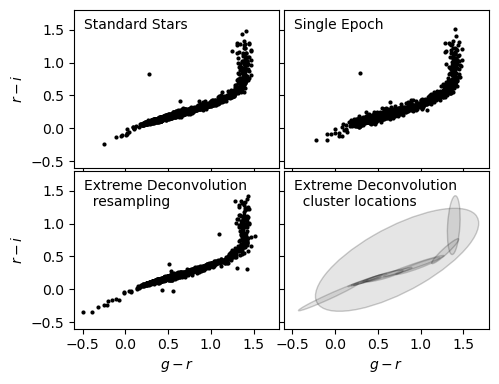

In [ ]:
# Fit and sample from the underlying distribution
np.random.seed(42)
X_sample = clf.sample(X.shape[0])

# plot the results
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(left=0.12, right=0.95,
                    bottom=0.1, top=0.95,
                    wspace=0.02, hspace=0.02)

# only plot 1/10 of the stars for clarity
ax1 = fig.add_subplot(221)
ax1.scatter(Y[::10, 2], Y[::10, 3], s=9, lw=0, c='k')

ax2 = fig.add_subplot(222)
ax2.scatter(X[::10, 2], X[::10, 3], s=9, lw=0, c='k')

ax3 = fig.add_subplot(223)
ax3.scatter(X_sample[::10, 2], X_sample[::10, 3], s=9, lw=0, c='k')

ax4 = fig.add_subplot(224)
for i in range(clf.n_components):
    draw_ellipse_(clf.mu[i, 2:4], clf.V[i, 2:4, 2:4], scales=[2],
                 ec='k', fc='gray', alpha=0.2, ax=ax4)

titles = ["Standard Stars", "Single Epoch",
          "Extreme Deconvolution\n  resampling",
          "Extreme Deconvolution\n  cluster locations"]
ax = [ax1, ax2, ax3, ax4]

for i in range(4):
    ax[i].set_xlim(-0.6, 1.8)
    ax[i].set_ylim(-0.6, 1.8)

    ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

    ax[i].text(0.05, 0.95, titles[i],
               ha='left', va='top', transform=ax[i].transAxes)

    if i in (0, 1):
        ax[i].xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_xlabel('$g-r$')

    if i in (1, 3):
        ax[i].yaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax[i].set_ylabel('$r-i$')

### B-8. Measure the width of the locus

Finally we quantify how thin the locus is, for each dataset.

We measure width along the **$w$ color**, a fixed combination
$$w = -0.227\,g + 0.792\,r - 0.567\,i + 0.05,$$
chosen (from the SDSS literature) to point **across** the stellar locus — perpendicular to it. So the spread in $w$ is literally the **thickness** of the locus.

We summarize that spread with $\sigma_G$, a robust width estimator based on the interquartile range:
$$\sigma_G = 0.7413\,(q_{75} - q_{25}),$$
which is far less sensitive to outliers than the ordinary standard deviation.

The XD-resampled data has the **smallest** $\sigma_G$ — a thinner locus than even the high-SNR standard stars — which is the quantitative payoff of the whole notebook: XD has stripped the measurement scatter back out, exactly the narrowing of $V_k$ described in the Introduction.

Text(0, 0.5, '$N(w)$')

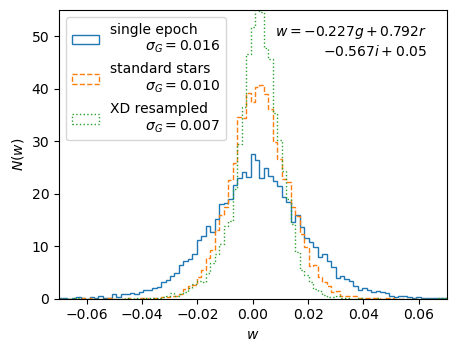

In [ ]:
# Width of the locus: histogram the w color for each dataset and measure its spread.
fig = plt.figure(figsize=(5, 3.75))
ax = fig.add_subplot(111)

labels = ['single epoch', 'standard stars', 'XD resampled']
linestyles = ['solid', 'dashed', 'dotted']
for data, label, ls in zip((X, Y, X_sample), labels, linestyles):
    g = data[:, 0]
    gr = data[:, 2]
    ri = data[:, 3]

    r = g - gr
    i = r - ri

    # restrict to a clean stretch of the locus
    mask = (gr > 0.3) & (gr < 1.0)
    g = g[mask]
    r = r[mask]
    i = i[mask]

    # w color points across the locus, so its spread measures the locus thickness
    w = -0.227 * g + 0.792 * r - 0.567 * i + 0.05

    # sigma_G: robust (IQR-based) width estimator
    sigma = sigmaG(w)

    ax.hist(w, bins=np.linspace(-0.08, 0.08, 100), linestyle=ls,
            histtype='step', label=label + '\n\t' + r'$\sigma_G=%.3f$' % sigma,
            density=True)

ax.legend(loc=2)
ax.text(0.95, 0.95, '$w = -0.227g + 0.792r$\n$ - 0.567i + 0.05$',
        transform=ax.transAxes, ha='right', va='top')

ax.set_xlim(-0.07, 0.07)
ax.set_ylim(0, 55)

ax.set_xlabel('$w$')
ax.set_ylabel('$N(w)$')

## Connection to DMASS

Part B is exactly the idea behind the **DMASS** algorithm, with the roles played by:

- **standard stars → CMASS** (the clean, well-characterized sample)
- **noisy single epoch → DES data** (the survey we want to model)

We cross-match CMASS with the DES data, then apply extreme deconvolution to the DES data. A separate notebook will walk through the full DMASS algorithm.